# BERTopic sobre columnas de opinión — corpus ciencia Colombia 2018–2020

**Estrategia de embedding**: cada columna (~700 palabras) se divide en fragmentos de ventana deslizante. Cada fragmento se codifica con `intfloat/multilingual-e5-large` y el embedding de la columna es el promedio de sus fragmentos. Esto respeta el límite de tokens del modelo sin truncar información.

**Selección de hiperparámetros**: se itera sobre `nr_topics` (y opcionalmente `min_topic_size`) evaluando coherencia c_v con `gensim`. El umbral de referencia para español es c_v ≥ 0.55.

## 0. Instalación de dependencias

In [2]:
# Ejecutar una sola vez
!pip install bertopic sentence-transformers gensim umap-learn hdbscan pandas openpyxl --quiet

## 1. Carga del corpus

In [3]:
import pandas as pd
import numpy as np

df = pd.read_excel('../../data/columnas_admin_ciencia.xlsx', parse_dates=['Fecha'])
df = df.dropna(subset=['Texto']).reset_index(drop=True)

textos = df['Texto'].tolist()
print(f"Documentos: {len(textos)}")
print(f"Longitud media (palabras): {df['Texto'].str.split().str.len().mean():.0f}")

Documentos: 2053
Longitud media (palabras): 698


## 2. Preprocesamiento y chunking

`intfloat/multilingual-e5-large` tiene límite de 512 tokens. Con columnas de ~700 palabras (~900 tokens) se usa ventana deslizante para no truncar.

In [4]:
def chunk_texto(texto, chunk_size=400, overlap=50):
    """
    Divide un texto en fragmentos de `chunk_size` palabras
    con solapamiento de `overlap` palabras entre fragmentos.
    Retorna lista de strings.
    """
    palabras = texto.split()
    if len(palabras) <= chunk_size:
        return [texto]
    chunks = []
    inicio = 0
    while inicio < len(palabras):
        fin = min(inicio + chunk_size, len(palabras))
        chunks.append(' '.join(palabras[inicio:fin]))
        if fin == len(palabras):
            break
        inicio += chunk_size - overlap
    return chunks

# Verificar: número de chunks por columna
chunks_por_doc = [len(chunk_texto(t)) for t in textos]
print(f"Chunks por documento — mín: {min(chunks_por_doc)}, máx: {max(chunks_por_doc)}, "
      f"media: {np.mean(chunks_por_doc):.2f}")

Chunks por documento — mín: 1, máx: 15, media: 2.35


## 3. Generación de embeddings con `intfloat/multilingual-e5-large`

El modelo requiere prefijo `query:` / `passage:`. Para indexación de corpus se usa `passage:`.

In [6]:
from sentence_transformers import SentenceTransformer

modelo_emb = SentenceTransformer('intfloat/multilingual-e5-large')

def embedding_documento(texto, modelo, chunk_size=400, overlap=50, batch_size=32):
    """
    Retorna el embedding promedio de los fragmentos del texto.
    Prefijo 'passage:' requerido por multilingual-e5.
    """
    chunks = chunk_texto(texto, chunk_size, overlap)
    chunks_prefijados = [f'passage: {c}' for c in chunks]
    embs = modelo.encode(
        chunks_prefijados,
        batch_size=batch_size,
        show_progress_bar=False,
        normalize_embeddings=True,
    )
    return embs.mean(axis=0)

In [8]:
from tqdm.auto import tqdm

embeddings = np.array([
    embedding_documento(t, modelo_emb)
    for t in tqdm(textos, desc='Embeddings')
])

print(f"Matriz de embeddings: {embeddings.shape}")

# Guardar para no recomputar
np.save('../../data/processed/embeddings_bertopic_admin_ciencia.npy', embeddings)


Embeddings:   0%|          | 0/2053 [00:00<?, ?it/s]

Matriz de embeddings: (2053, 1024)


In [9]:
# Cargar embeddings guardados (saltar celda anterior si ya existen)
# embeddings = np.load('embeddings_bertopic_admin_ciencia.npy')

## 4. Configuración base de BERTopic

In [10]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOPWORDS_ES = list(stopwords.words('spanish'))

# Stopwords manuales del dominio (basadas en EDA)
STOPWORDS_DOMINIO = [
    'puede', 'solo', 'hace', 'bien', 'menos', 'sido', 'gran', 'mismo',
    'todas', 'deben', 'ello', 'siempre', 'aunque', 'mientras', 'hacia',
    'embargo', 'después', 'según', 'frente', 'pues', 'mayor', 'mejor',
    'nuevo', 'forma', 'ejemplo', 'cuenta', 'parte', 'caso', 'hecho', 'vez',
    'grandes', 'general', 'importante', 'posible', 'cosas', 'muchas',
    'cualquier', 'tres', 'primera', 'ello', 'lugar', 'debe', 'hacer',
    'tener', 'decir', 'pueden', 'además', 'ahora', 'también', 'sino',
    'tan', 'pues', 'manera', 'millones', 'tiempo', 'vida', 'cambio',
    'proceso', 'acuerdo', 'sistema', 'personas', 'colombia', 'país',
    'países', 'año', 'años', 'mundo', 'nuevo', 'nueva',
]

STOPWORDS_ALL = list(set(STOPWORDS_ES + STOPWORDS_DOMINIO))

def make_bertopic(nr_topics, min_topic_size=10):
    """
    Construye un modelo BERTopic con los parámetros dados.
    Los embeddings se pasan externamente (ya computados).
    """
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_topic_size,
        min_samples=5,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True,
    )
    vectorizer = CountVectorizer(
        stop_words=STOPWORDS_ALL,
        min_df=3,
        ngram_range=(1, 2),
    )
    model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        nr_topics=nr_topics,      # None = sin reducción; int = reducir a N
        top_n_words=10,
        calculate_probabilities=False,
        verbose=False,
    )
    return model

## 5. Función de coherencia c_v con gensim

In [11]:
import re
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

def tokenizar(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)
    return [t for t in texto.split() if t not in STOPWORDS_ALL and len(t) > 3]

# Corpus tokenizado para gensim (se computa una sola vez)
corpus_tokenizado = [tokenizar(t) for t in textos]
diccionario_gensim = Dictionary(corpus_tokenizado)

def calcular_coherencia(topic_words, corpus_tok, dictionary):
    """
    Calcula coherencia c_v para una lista de listas de palabras (tópicos).
    Excluye el tópico -1 (outliers de BERTopic).
    """
    topics_filtrados = [t for t in topic_words if t]  # eliminar vacíos
    if len(topics_filtrados) < 2:
        return np.nan
    cm = CoherenceModel(
        topics=topics_filtrados,
        texts=corpus_tok,
        dictionary=dictionary,
        coherence='c_v',
    )
    return cm.get_coherence()

## 6. Búsqueda de `nr_topics` óptimo

Se itera sobre un rango de valores. Para cada uno se entrena BERTopic (pasando los embeddings ya computados) y se calcula coherencia c_v. El umbral de referencia del proyecto es **c_v ≥ 0.55**.

In [12]:
import warnings
warnings.filterwarnings('ignore')

# Rango a explorar — ajustar según tiempo disponible
NR_TOPICS_RANGO = [10, 15, 20, 25, 30, 40, 50]
MIN_TOPIC_SIZE  = 10   # puedes también iterar sobre esto

resultados = []

for nr in tqdm(NR_TOPICS_RANGO, desc='nr_topics'):
    model = make_bertopic(nr_topics=nr, min_topic_size=MIN_TOPIC_SIZE)
    topics, _ = model.fit_transform(textos, embeddings=embeddings)

    # Palabras por tópico (excluir -1)
    topic_words = [
        [w for w, _ in model.get_topic(t)]
        for t in model.get_topics()
        if t != -1
    ]

    n_topics_reales  = len(set(topics)) - (1 if -1 in topics else 0)
    pct_outliers     = (np.array(topics) == -1).mean() * 100
    coherencia       = calcular_coherencia(topic_words, corpus_tokenizado, diccionario_gensim)

    resultados.append({
        'nr_topics_param'  : nr,
        'n_topics_reales'  : n_topics_reales,
        'pct_outliers'     : round(pct_outliers, 2),
        'coherencia_cv'    : round(coherencia, 4),
    })
    print(f"nr={nr:3d} | tópicos={n_topics_reales:3d} | outliers={pct_outliers:.1f}% | c_v={coherencia:.4f}")

df_resultados = pd.DataFrame(resultados)
df_resultados

nr_topics:   0%|          | 0/7 [00:00<?, ?it/s]

nr= 10 | tópicos=  9 | outliers=33.8% | c_v=0.6730
nr= 15 | tópicos= 14 | outliers=33.8% | c_v=0.6710
nr= 20 | tópicos= 19 | outliers=33.8% | c_v=0.7064
nr= 25 | tópicos= 24 | outliers=33.8% | c_v=0.6968
nr= 30 | tópicos= 29 | outliers=33.8% | c_v=0.6946
nr= 40 | tópicos= 39 | outliers=33.8% | c_v=0.6890
nr= 50 | tópicos= 49 | outliers=33.8% | c_v=0.6904


,nr_topics_param,n_topics_reales,pct_outliers,coherencia_cv
0,10,9,33.8,0.6730
1,15,14,33.8,0.6710
2,20,19,33.8,0.7064
3,25,24,33.8,0.6968
4,30,29,33.8,0.6946
5,40,39,33.8,0.6890
6,50,49,33.8,0.6904


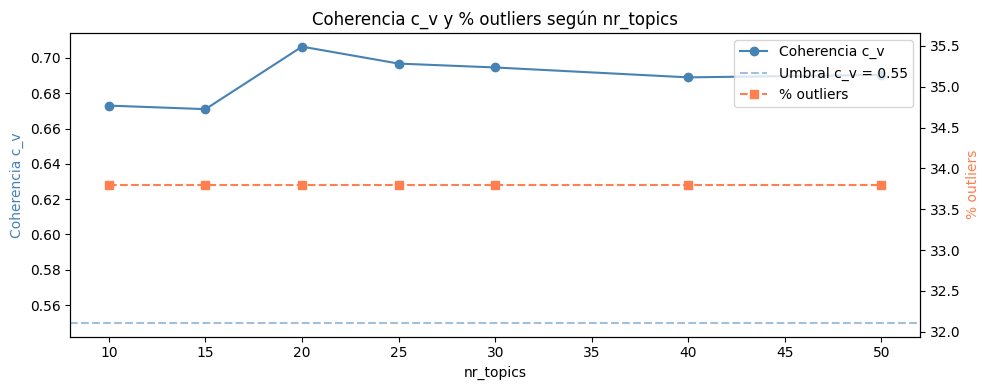

In [13]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df_resultados['nr_topics_param'], df_resultados['coherencia_cv'],
         marker='o', color='steelblue', label='Coherencia c_v')
ax1.axhline(0.55, color='steelblue', linestyle='--', alpha=0.5, label='Umbral c_v = 0.55')
ax1.set_xlabel('nr_topics')
ax1.set_ylabel('Coherencia c_v', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_resultados['nr_topics_param'], df_resultados['pct_outliers'],
         marker='s', color='coral', linestyle='--', label='% outliers')
ax2.set_ylabel('% outliers', color='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Coherencia c_v y % outliers según nr_topics')
plt.tight_layout()
plt.savefig('coherencia_vs_nrtopics.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Modelo final con el `nr_topics` óptimo

In [14]:
# Seleccionar el nr_topics con mayor coherencia c_v
mejor_fila    = df_resultados.loc[df_resultados['coherencia_cv'].idxmax()]
NR_OPTIMO     = int(mejor_fila['nr_topics_param'])
print(f"nr_topics óptimo: {NR_OPTIMO} — c_v={mejor_fila['coherencia_cv']:.4f}, "
      f"outliers={mejor_fila['pct_outliers']}%")

nr_topics óptimo: 20 — c_v=0.7064, outliers=33.8%


In [15]:
model_final = make_bertopic(nr_topics=NR_OPTIMO, min_topic_size=MIN_TOPIC_SIZE)
topics_final, probs_final = model_final.fit_transform(textos, embeddings=embeddings)

df['topic'] = topics_final
print(model_final.get_topic_info())

    Topic  Count                                               Name  \
0      -1    694                                   -1_ms_ser_si_pas   
1       0    353                          0_gobierno_poltica_ms_pas   
2       1    209                         1_ms_desarrollo_pas_sector   
3       2    186                             2_ms_ser_mujeres_poder   
4       3    147                             3_ms_bogot_ciudad_agua   
5       4     77                          4_pandemia_ms_salud_virus   
6       5     70  5_educacin_universidades_superior_educacin sup...   
7       6     56                6_datos_informacin_internet_digital   
8       7     50  7_universidad_nacional_universidad nacional_ed...   
9       8     44             8_organizaciones_organizacin_ser_plazo   
10      9     33                         9_trump_unidos_china_biden   
11     10     29              10_estudiantes_educacin_nios_colegios   
12     11     28             11_dficit_corriente_fiscal_crecimiento   
13    

## 8. Inspección de tópicos

In [16]:
# Tabla de tópicos con palabras clave
topic_info = model_final.get_topic_info()
topic_info = topic_info[topic_info['Topic'] != -1].copy()

# Añadir coherencia individual por tópico
coherencias_ind = {}
for t in topic_info['Topic']:
    palabras = [w for w, _ in model_final.get_topic(t)]
    try:
        c = calcular_coherencia([palabras], corpus_tokenizado, diccionario_gensim)
    except Exception:
        c = np.nan
    coherencias_ind[t] = round(c, 4)

topic_info['coherencia_cv'] = topic_info['Topic'].map(coherencias_ind)
topic_info.sort_values('coherencia_cv', ascending=False)

,Topic,Count,Name,Representation,Representative_Docs,coherencia_cv
1,0,353,0_gobierno_poltica_ms_pas,"[gobierno, poltica, ms, pas, paz, presidente, ...","[El 22 de mayo, 48 horas después del fracaso o...",NaN
2,1,209,1_ms_desarrollo_pas_sector,"[ms, desarrollo, pas, sector, economa, gobiern...",[Mal cierre de año para el sector agropecuario...,NaN
3,2,186,2_ms_ser_mujeres_poder,"[ms, ser, mujeres, poder, tambin, si, poltica,...","[Las viejas calles de Atenas, como las de tant...",NaN
4,3,147,3_ms_bogot_ciudad_agua,"[ms, bogot, ciudad, agua, ambientales, alcalde...",[La deforestación abierta y sin control en la ...,NaN
5,4,77,4_pandemia_ms_salud_virus,"[pandemia, ms, salud, virus, economa, vacuna, ...","[Como un par de muletas, los profesionales de ...",NaN
6,5,70,5_educacin_universidades_superior_educacin sup...,"[educacin, universidades, superior, educacin s...","[A diferencia de otros momentos históricos, en...",NaN
7,6,56,6_datos_informacin_internet_digital,"[datos, informacin, internet, digital, ley, te...","[Telia, empresa de telecomunicaciones con nego...",NaN
8,7,50,7_universidad_nacional_universidad nacional_ed...,"[universidad, nacional, universidad nacional, ...",[En mis 35 años de experiencia como docente e ...,NaN
9,8,44,8_organizaciones_organizacin_ser_plazo,"[organizaciones, organizacin, ser, plazo, estr...","[Cuando se habla de retorno de inversión, en l...",NaN
10,9,33,9_trump_unidos_china_biden,"[trump, unidos, china, biden, ms, comercio, pr...",[Comenzando el 2020 las elecciones en Estados ...,NaN


In [17]:
# Visualización interactiva de tópicos (requiere plotly)
model_final.visualize_topics()

In [18]:
# Barras de palabras clave por tópico
model_final.visualize_barchart(top_n_topics=15, n_words=8)

## 9. Distribución de tópicos por periódico y en el tiempo

In [19]:
# Distribución por periódico (excluir outliers)
df_temas = df[df['topic'] != -1].copy()

pivot_diario = (
    df_temas.groupby(['Diario', 'topic'])
            .size()
            .unstack(fill_value=0)
)
# Normalizar por filas (proporción dentro de cada periódico)
pivot_diario_pct = pivot_diario.div(pivot_diario.sum(axis=1), axis=0).round(3)
pivot_diario_pct

topic,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Diario,,,,,,,,,,,,,,,,,,,
El Espectador,0.235,0.153,0.144,0.081,0.063,0.054,0.047,0.046,0.040,0.027,0.025,0.027,0.010,0.010,0.01,0.007,0.008,0.009,0.006
El Tiempo,0.269,0.160,0.166,0.143,0.063,0.040,0.040,0.011,0.011,0.023,0.011,0.000,0.006,0.006,0.00,0.011,0.011,0.006,0.023
Semana,0.440,0.149,0.045,0.276,0.000,0.045,0.000,0.000,0.000,0.007,0.007,0.000,0.015,0.007,0.00,0.007,0.000,0.000,0.000


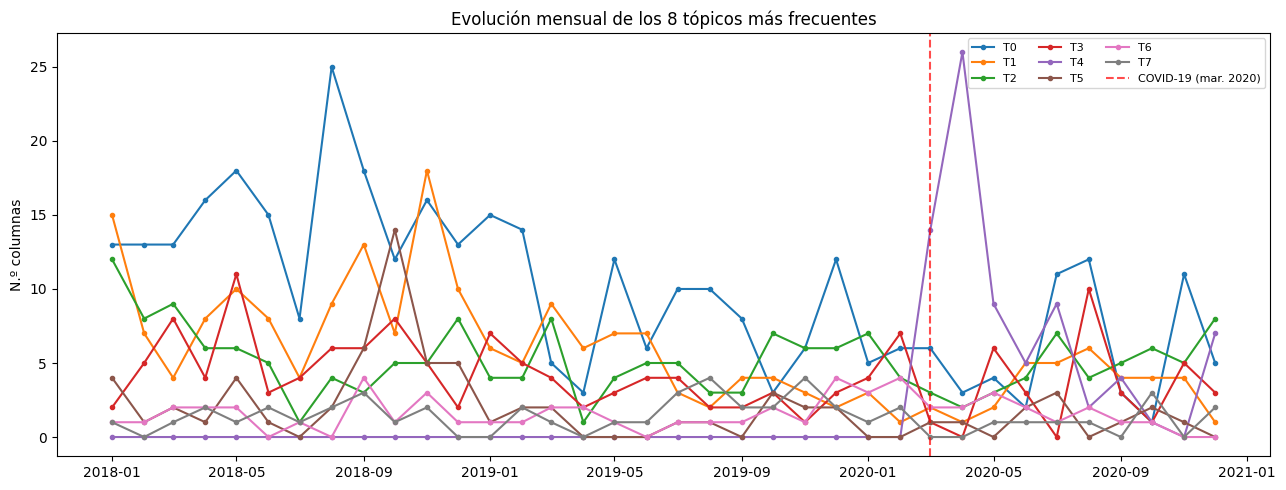

In [20]:
# Evolución temporal de tópicos (mensual)
df_temas['AñoMes'] = df_temas['Fecha'].dt.to_period('M')

pivot_mensual = (
    df_temas.groupby(['AñoMes', 'topic'])
            .size()
            .unstack(fill_value=0)
)

# Seleccionar los 8 tópicos más frecuentes para graficar
top8 = df_temas['topic'].value_counts().head(8).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
for t in top8:
    if t in pivot_mensual.columns:
        serie = pivot_mensual[t]
        ax.plot(serie.index.to_timestamp(), serie.values,
                marker='o', markersize=3, label=f'T{t}')

# Marcar inicio COVID
ax.axvline(pd.Timestamp('2020-03-01'), color='red',
           linestyle='--', alpha=0.7, label='COVID-19 (mar. 2020)')
ax.legend(ncol=3, fontsize=8)
ax.set_ylabel('N.º columnas')
ax.set_title('Evolución mensual de los 8 tópicos más frecuentes')
plt.tight_layout()
plt.savefig('topics_evolucion_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Exportar resultados

In [21]:
# Guardar modelo
model_final.save('bertopic_modelo_final')

# Exportar corpus con asignaciones
df.to_parquet('corpus_con_topics.parquet', index=False)

# Exportar tabla de tópicos
with pd.ExcelWriter('resultados_bertopic.xlsx', engine='openpyxl') as writer:
    topic_info.to_excel(writer, sheet_name='topics_info', index=False)
    df_resultados.to_excel(writer, sheet_name='busqueda_nr_topics', index=False)
    pivot_diario_pct.to_excel(writer, sheet_name='topics_por_diario')

print('Exportado: bertopic_modelo_final/, corpus_con_topics.parquet, resultados_bertopic.xlsx')

2026-06-27 00:23:56,045 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


ArrowTypeError: ("Expected bytes, got a 'int' object", 'Conversion failed for column Título with type object')